In [1]:
# Ran with predictors_simple kernel
# Python 3.10.8

import numpy as np # 1.26.4
import pandas as pd # 2.2.3
import tensorflow as tf # 2.10.0
import matplotlib # 3.10.3
import torch # 2.0.0

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.sans-serif'] = 'Arial'
from matplotlib import pyplot as plt

from joblib import load
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import auc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns
import re

import os

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Model")
from ADModel_three_state import ADModel_three_state_abund
from ADModel_two_state import ADModel_two_state_abund
from Data import DataReader, SplitData, FastTensorDataLoader, one_hot_encode


os.chdir("/Users/claireleblanc/Documents/tools_software/adhunter")
from actpred.models import ActCNNSystem

# Set Numpy to display floats with 3 decimal places
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction")

In [2]:
# Reading in the full length sequences and tile data

data = pd.read_csv("Data/Unique_502_Gcn4_Seqs_three_clusters.csv", index_col=0)
test_seqs= data[data["heirarchical"] == 1]
val_seqs= data[data["heirarchical"] == 2]
train_seqs = data[data["heirarchical"] == 3]

tile_data = pd.read_csv("Data/pm_gcn4_sort2_pools_allchannels_wrangled.csv")

activity_dict = {}
for i in tile_data.index:
    activity_dict[tile_data.loc[i,"aa_seq"]] = tile_data.loc[i,"activity"]

abund_dict = {}
for i in tile_data.index:
    abund_dict[tile_data.loc[i,"aa_seq"]] = tile_data.loc[i,"abundance"]

used_tiles = []

def get_tile_activity(tile):
    used_tiles.append(tile)
    return activity_dict.get(tile)

def get_tile_abundance(tile):
    return abund_dict.get(tile)


# Break full length seqs into tiles, adding in the final tile
test_seqs["40_tiles"] = [[seq[i:i+40] for i in range(0,len(seq)-39,5)] + [seq[-40:]] for seq in test_seqs["Sequence"]]
test_seqs["40_tile_centers"] = [[i+20 for i in range(0,len(seq)-39,5)] + [len(seq)-20] for seq in test_seqs["Sequence"]]
test_seqs["40_tiles_exp_activities"] = [[get_tile_activity(tile) for tile in tiles] for tiles in test_seqs["40_tiles"]]
test_seqs["40_tiles_exp_abundance"] = [[get_tile_abundance(tile) for tile in tiles] for tiles in test_seqs["40_tiles"]]

val_seqs["40_tiles"] = [[seq[i:i+40] for i in range(0,len(seq)-39,5)] + [seq[-40:]] for seq in val_seqs["Sequence"]]
val_seqs["40_tile_centers"] = [[i+20 for i in range(0,len(seq)-39,5)] + [len(seq)-20] for seq in val_seqs["Sequence"]]
val_seqs["40_tiles_exp_activities"] = [[get_tile_activity(tile) for tile in tiles] for tiles in val_seqs["40_tiles"]]
val_seqs["40_tiles_exp_abundance"] = [[get_tile_abundance(tile) for tile in tiles] for tiles in val_seqs["40_tiles"]]

train_seqs["40_tiles"] = [[seq[i:i+40] for i in range(0,len(seq)-39,5)] + [seq[-40:]] for seq in train_seqs["Sequence"]]
train_seqs["40_tile_centers"] = [[i+20 for i in range(0,len(seq)-39,5)] + [len(seq)-20] for seq in train_seqs["Sequence"]]
train_seqs["40_tiles_exp_activities"] = [[get_tile_activity(tile) for tile in tiles] for tiles in train_seqs["40_tiles"]]
train_seqs["40_tiles_exp_abundance"] = [[get_tile_abundance(tile) for tile in tiles] for tiles in train_seqs["40_tiles"]]

unused_tiles = list(set(tile_data["aa_seq"]).difference(set(used_tiles)))
other_tiles = pd.DataFrame(unused_tiles, columns=["aa_seq"])
other_tiles["activity"] = [get_tile_activity(s) for s in other_tiles["aa_seq"]]
other_tiles["abundance"] = [get_tile_abundance(s) for s in other_tiles["aa_seq"]]


/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_36250/975632502.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_seqs["40_tiles"] = [[seq[i:i+40] for i in range(0,len(seq)-39,5)] + [seq[-40:]] for seq in test_seqs["Sequence"]]
/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_36250/975632502.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_seqs["40_tile_centers"] = [[i+20 for i in range(0,len(seq)-39,5)] + [len(seq)-20] for seq in test_seqs["Sequence"]]
/var/folders/34/

In [22]:
# For two state model:
# This is an attempt to choose the "best" model in an unbiased way
# Specifically, it tries to choose a model that has both a high pearson and a high spearman correlation
# It does this by choosing the model with the highest combined spearman and pearson rank

# two_model_results = pd.read_csv("results/results_two_state_test_larger_LR.csv")
# two_model_results = pd.read_csv("results/results_two_state_test_relu.csv")
two_model_results = pd.read_csv('results/results_two_state_test_leakyrelu.csv')

two_model_results = two_model_results.sort_values("pearson_act_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r1"] = two_model_results.index

two_model_results = two_model_results.sort_values("spearman_act_val", ascending=False)
two_model_results = two_model_results.reset_index()
two_model_results["r2"] = two_model_results.index
two_model_results = two_model_results.drop(columns="level_0")


# two_model_results = two_model_results.sort_values("pearson_act_val", ascending=False)
# two_model_results = two_model_results.reset_index()
# two_model_results["r3"] = two_model_results.index

# two_model_results = two_model_results.sort_values("spearman_act_val", ascending=False)
# two_model_results = two_model_results.reset_index()
# two_model_results["r4"] = two_model_results.index
# two_model_results = two_model_results.drop(columns="level_0")


two_model_results["max_rank"] = two_model_results[["r1","r2",]].max(axis=1)            # min–max rule
two_model_results["sum_rank"] = two_model_results["r1"] + two_model_results["r2"]               # Borda

In [6]:
# Running the two-state biophysical model on the data

# Biophysical model parameters
size = (1,40,20)
hill_value = 1
# relu = False
relu = False
outchannel = 1

# Loading the "best" model, as defined above based on val data
# We also are filtering to use Hill value as that gave systematically better pearson correlations
model = 'model_data/two_state_abundmodel_b10_e200_L0.001_sMinMax_aHill_c1_k1_ak5_LeakyReLU_0.5PosKLoss_0.1PosWeightLoss_hSplit_hv1_seed830655019_weightInit_v2'
kernel_size_two = 1
abund_k_two = int(re.search(r'ak(\d+)',model).group(1))
activity_fun = "Hill"

two_state_biophysical_model = ADModel_two_state_abund(size,activity_fun, kernel_size_two, relu=relu, abund_k=abund_k_two)
two_state_biophysical_model.load_state_dict(torch.load(f"{model}.pth"))

two_state_biophysical_model.eval()

# Loading the scaler
sc_act = load("Model/scaler_activity.bin")
sc_abund = load("Model/scaler_activity.bin")


def run_biophysical_model(loaded_model,sequence):
    """
    Takes a sequence and run the model on sequence
    """
    encoded_seq = one_hot_encode(sequence).reshape(1,1,40,20)
    seq_tensor = torch.from_numpy(encoded_seq).type(torch.FloatTensor)
    predictions = loaded_model(seq_tensor)
    predictions_act = sc_act.inverse_transform(predictions.detach().numpy().reshape(-1)[1].reshape(1,-1))
    predictions_abund = sc_abund.inverse_transform(predictions.detach().numpy().reshape(-1)[0].reshape(1,-1))
    return predictions_abund, predictions_act

# Run biophysical model on all the sequences
test_seqs["biophysics_gfp_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[1] for tile in tiles] for tiles in test_seqs["40_tiles"]]
val_seqs["biophysics_gfp_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[1] for tile in tiles] for tiles in val_seqs["40_tiles"]]
train_seqs["biophysics_gfp_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[1] for tile in tiles] for tiles in train_seqs["40_tiles"]]
other_tiles["biophysics_gfp_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[1] for tile in other_tiles["aa_seq"]]

test_seqs["biophysics_mcherry_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[0] for tile in tiles] for tiles in test_seqs["40_tiles"]]
val_seqs["biophysics_mcherry_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[0] for tile in tiles] for tiles in val_seqs["40_tiles"]]
train_seqs["biophysics_mcherry_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[0] for tile in tiles] for tiles in train_seqs["40_tiles"]]
other_tiles["biophysics_mcherry_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[0] for tile in other_tiles["aa_seq"]]


/Users/claireleblanc/miniconda3/envs/predictors_simple/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_36250/831876458.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_seqs["biophysics_gfp_pred_2"] = [[run_biophysical_model(two_state_biophysical_model, tile)[1] for tile in tiles] for tiles in test_seqs["40_tiles"]]
/var/folders/34/1pw3__x51kdfyh3vk72f5vc

In [8]:
tile_data = pd.read_csv("Data/pm_gcn4_sort2_pools_allchannels_wrangled.csv")

In [14]:
encoded_seqs = []
for seq in tile_data['aa_seq']:
    encoded_seqs.append(one_hot_encode(seq).reshape(1,1,40,20))
seq_tensor = torch.from_numpy(np.array(encoded_seqs)).type(torch.FloatTensor).squeeze(1)
predictions = two_state_biophysical_model(seq_tensor)

In [19]:
Ks = two_state_biophysical_model.get_ks()[0].detach().numpy()
abund = two_state_biophysical_model.get_ks()[1].detach().numpy()

In [21]:
max(Ks)

array([0.539], dtype=float32)

(array([9206.000, 2595.000, 2538.000, 1770.000, 1091.000, 418.000, 89.000,
        19.000, 4.000, 2.000]),
 array([-0.003, 0.051, 0.105, 0.159, 0.214, 0.268, 0.322, 0.376, 0.430,
        0.484, 0.539]),
 <BarContainer object of 10 artists>)

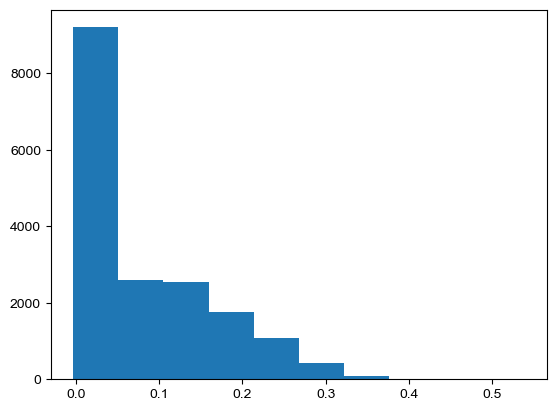

In [18]:
plt.hist(Ks)